## Check the window function

In [2]:
import os, sys
import lsstypes as types
import numpy as np
from matplotlib import pyplot as plt

sys.path.append('../../')
from helper import REDSHIFT_BIN_LSS

In [3]:
def unpack_obs(result):
    k = result.get(ells=0).coords('k')
    pk = [result.get(ells=ell).values()['value'] for ell in result.ells]
    return k, pk

In [4]:
tracer = 'LRG'
zrange = REDSHIFT_BIN_LSS[tracer][0]

local_fn = f'/pscratch/sd/s/shengyu/galaxies/catalogs/Y3/AbacusHF-v2/altmtl/LRG/mock0/mpspk/window_mesh2_spectrum_poles_{tracer}_z{zrange[0]}-{zrange[1]}_DR2_v2.0.h5'
save_fn  = f'/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/base/abacus-hf-dr2-v2-altmtl/mock0/window_mesh2_spectrum_poles_{tracer}_z{zrange[0]}-{zrange[1]}_GCcomb_weight-default-FKP.h5'
print(local_fn)
print(save_fn)

win1 =types.read(local_fn)
win2 =types.read(save_fn)

W1 = win1.value().real
W2 = win2.value().real

/pscratch/sd/s/shengyu/galaxies/catalogs/Y3/AbacusHF-v2/altmtl/LRG/mock0/mpspk/window_mesh2_spectrum_poles_LRG_z0.4-0.6_DR2_v2.0.h5
/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/base/abacus-hf-dr2-v2-altmtl/mock0/window_mesh2_spectrum_poles_LRG_z0.4-0.6_GCcomb_weight-default-FKP.h5


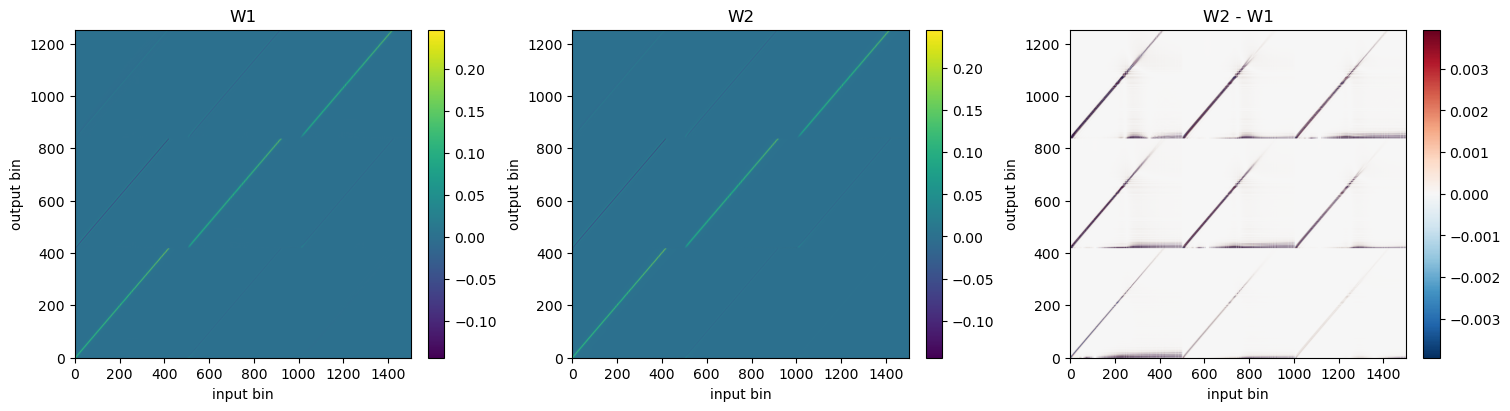

In [5]:
dW = W1-W2

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

im0 = axes[0].imshow(W1, aspect="auto", origin="lower")
axes[0].set_title("W1")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(W2, aspect="auto", origin="lower")
axes[1].set_title("W2")
plt.colorbar(im1, ax=axes[1])

vmax = np.nanpercentile(np.abs(dW), 99)
im2 = axes[2].imshow(dW, aspect="auto", origin="lower", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axes[2].set_title("W2 - W1")
plt.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.set_xlabel("input bin")
    ax.set_ylabel("output bin")

In [6]:
kin, pk_zero = unpack_obs(win1.theory)
kin = np.asarray(kin)
n = len(kin)

W1 = win1.value().real
W2 = win2.value().real

assert W1.shape[1] % n == 0, (W1.shape[1], n)
nell_in = W1.shape[1] // n

# Simple nonzero smooth test theory.
# Ordering: [P0(k), P2(k), P4(k)]
pk = np.zeros((nell_in, n))
pk[0] = 1.0 / (1.0 + (kin / 0.15)**2)

if nell_in > 1:
    pk[1] = 0.3 * pk[0]
if nell_in > 2:
    pk[2] = 0.05 * pk[0]

theory_in = pk.reshape(-1)

y1 = W1 @ theory_in
y2 = W2 @ theory_in
dy = y2 - y1

den = np.linalg.norm(y1)

stats = {
    "norm_y1": den,
    "norm_y2": np.linalg.norm(y2),
    "relative_output_diff": np.linalg.norm(dy) / den if den != 0 else np.nan,
    "rms_output_diff": np.sqrt(np.mean(dy**2)),
    "max_abs_output_diff": np.max(np.abs(dy)),
    "mean_abs_output_diff": np.mean(np.abs(dy)),
}

stats

{'norm_y1': 11.152121842024787,
 'norm_y2': 11.150650972245673,
 'relative_output_diff': 0.0008770088558499318,
 'rms_output_diff': 0.0002761930310577523,
 'max_abs_output_diff': 0.005709309564199794,
 'mean_abs_output_diff': 4.566820138998807e-05}

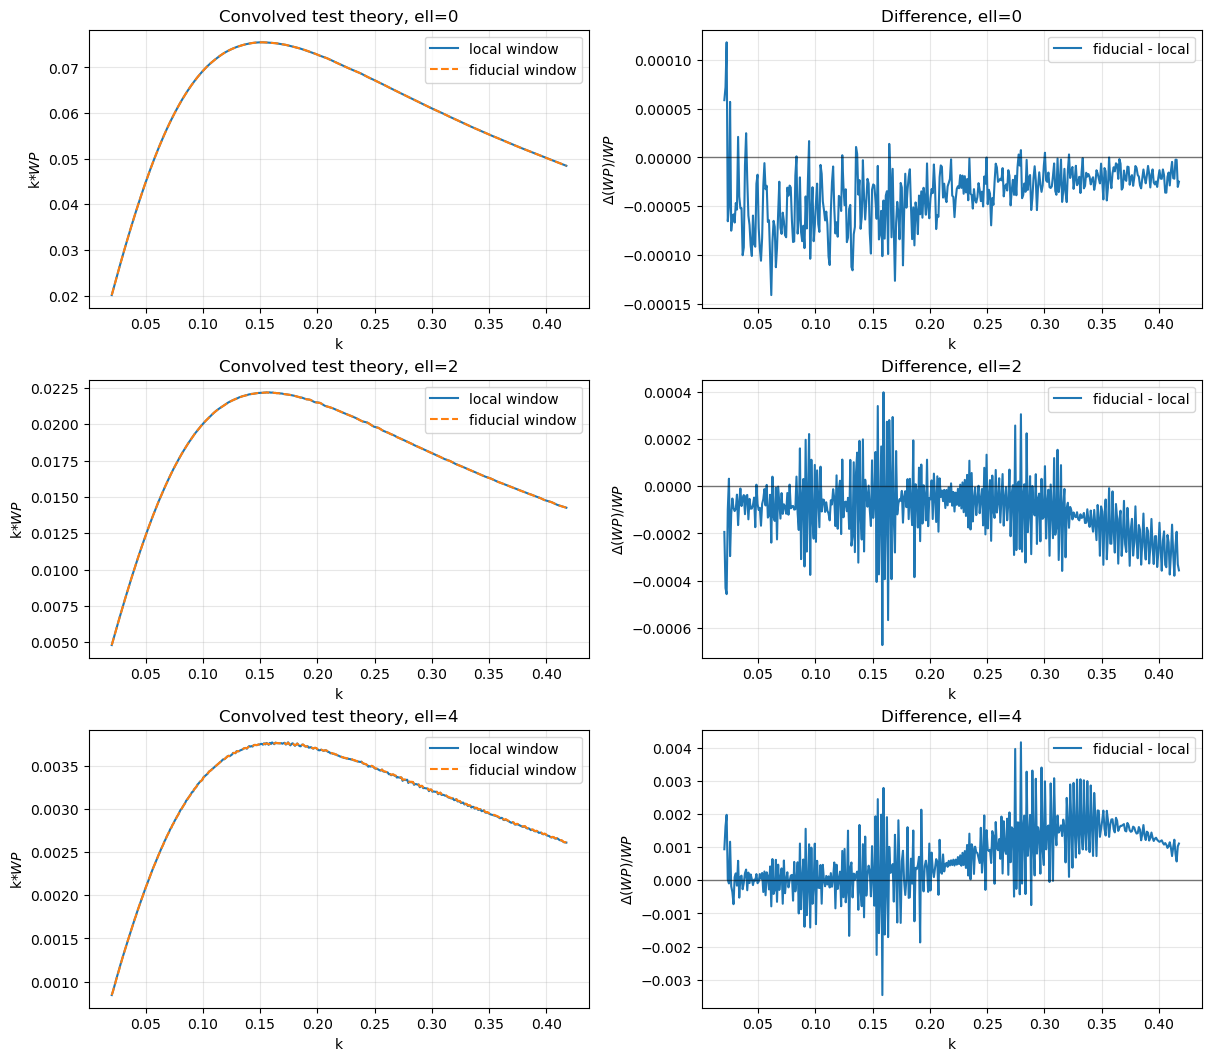

In [7]:
kout, _ = unpack_obs(win1.observable)
kout = np.asarray(kout)
nout = len(kout)

assert W1.shape[0] % nout == 0, (W1.shape[0], nout)
nell_out = W1.shape[0] // nout

ells = list(win1.observable.ells)

fig, axes = plt.subplots(nell_out, 2, figsize=(12, 3.5 * nell_out), constrained_layout=True)

if nell_out == 1:
    axes = np.array([axes])

ncut=20
kout = kout[ncut:]

for iell in range(nell_out):
    sl = slice(iell * nout, (iell + 1) * nout)
    ell = ells[iell]

    y1_ell = y1[sl][ncut:]
    y2_ell = y2[sl][ncut:]
    dy_ell = dy[sl][ncut:]

    axes[iell, 0].plot(kout, kout*y1_ell, label="local window")
    axes[iell, 0].plot(kout, kout*y2_ell, "--", label="fiducial window")
    axes[iell, 0].set_title(f"Convolved test theory, ell={ell}")
    axes[iell, 0].set_xlabel("k")
    axes[iell, 0].set_ylabel(r"k*$W P$")
    axes[iell, 0].grid(alpha=0.3)
    axes[iell, 0].legend()

    axes[iell, 1].plot(kout, dy_ell/y1_ell, label="fiducial - local")
    axes[iell, 1].axhline(0, color="k", lw=1, alpha=0.5)
    axes[iell, 1].set_title(f"Difference, ell={ell}")
    axes[iell, 1].set_xlabel("k")
    axes[iell, 1].set_ylabel(r"$\Delta(WP)/ WP$")
    axes[iell, 1].grid(alpha=0.3)
    axes[iell, 1].legend()